# Testing for PR#9 — BHPTNRSur1dq1e4 Comparison

Compare BHPTNRSur1dq1e4 waveforms from three sources:
- **PR#9**: Current repo (`Research/projects/stupid/BHPTNRSurrogate`)
- **BHPTSur/Old**: Previous version (`Research/pool/BHPTNRSurrogate`)
- **gwsur**: gwsurrogate package

For q=3, q=10, and q=100, we compare max differences in complex waveform, amplitude, and phase for each mode.

In [1]:
import sys
import warnings
import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## Loading Models

In [2]:
# PR#9: current repo
sys.path.insert(0, '/Users/tousifislam/Research/projects/stupid/BHPTNRSurrogate')
from BHPTNRSurrogate.surrogates import BHPTNRSur1dq1e4 as sur_pr9
sur_pr9._ensure_loaded()
print('PR#9 model loaded')

/Users/tousifislam/miniforge3/lib/python3.12/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun
PR#9 model loaded


In [3]:
# BHPTSur/Old: previous version
old_path = '/Users/tousifislam/Research/pool/BHPTNRSurrogate/surrogates'
sys.path.insert(0, old_path)
try:
    sur_old = importlib.import_module('BHPTNRSur1dq1e4')
    OLD_AVAILABLE = True
    print('BHPTSur/Old model loaded')
except Exception as e:
    print(f'Failed to load BHPTSur/Old: {e}')
    OLD_AVAILABLE = False

**** Surrogate loaded: BHPTNRSur1dq1e4 ****
BHPTSur/Old model loaded


In [4]:
# gwsurrogate — uses EvaluateSurrogate (not LoadSurrogate) for this model
import os
try:
    import gwsurrogate as gws
    gwsur_dir = os.path.join(os.path.dirname(gws.__file__), 'surrogate_downloads')
    gwsur_path = os.path.join(gwsur_dir, 'BHPTNRSur1dq1e4.h5')
    if not os.path.exists(gwsur_path):
        gwsur_path = gws.catalog.pull('BHPTNRSur1dq1e4')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sur_gw = gws.EvaluateSurrogate(gwsur_path)
    GW_AVAILABLE = True
    print('gwsurrogate model loaded')
except Exception as e:
    print(f'Failed to load gwsurrogate: {e}')
    GW_AVAILABLE = False

loading surrogate mode... l10_m8

>>> Found surrogate ID from file name: BHPTNRSur1dq1e4

>>> Warning: Guessing quadrature weights to be identical with 0.200000
Cannot load greedy points...OK
Special case: using spline for parametric model at each EI node
num_fits_re = 16
num_fits_im = 16
setting norm fitparams to None...
loading surrogate mode... l10_m9

>>> Found surrogate ID from file name: BHPTNRSur1dq1e4

>>> Warning: Guessing quadrature weights to be identical with 0.200000
Cannot load greedy points...OK
Special case: using spline for parametric model at each EI node
num_fits_re = 16
num_fits_im = 16
setting norm fitparams to None...
loading surrogate mode... l2_m1

>>> Found surrogate ID from file name: BHPTNRSur1dq1e4

>>> Warning: Guessing quadrature weights to be identical with 0.200000
Cannot load greedy points...OK
Special case: using spline for parametric model at each EI node
num_fits_re = 13
num_fits_im = 13
setting norm fitparams to None...
loading surrogate mode... l2_

In [5]:
# Determine gwsurrogate strain convention by comparing (2,2) with PR#9
if GW_AVAILABLE:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        t_ref, h_ref = sur_pr9.generate_surrogate(q=5, modes=[(2,2)], neg_modes=False)
        result_gw = sur_gw(5, mode_sum=False, fake_neg_modes=False)

    modes_gw_test, t_gw_test, hp_test, hc_test = result_gw
    idx22 = next(i for i, m in enumerate(modes_gw_test)
                 if list(m) == [2, 2] or tuple(m) == (2, 2))
    hp_22 = hp_test[:, idx22] if hp_test.ndim > 1 else hp_test
    hc_22 = hc_test[:, idx22] if hc_test.ndim > 1 else hc_test

    t_lo = max(t_ref[0], t_gw_test[0])
    t_hi = min(t_ref[-1], t_gw_test[-1])
    mask = (t_gw_test >= t_lo) & (t_gw_test <= t_hi)
    t_c = t_gw_test[mask]
    h_ref_c = (interp1d(t_ref, h_ref[(2,2)].real, 'cubic')(t_c)
              + 1j * interp1d(t_ref, h_ref[(2,2)].imag, 'cubic')(t_c))

    conventions = {
        'hp + 1j*hc': hp_22[mask] + 1j * hc_22[mask],
        'hp - 1j*hc': hp_22[mask] - 1j * hc_22[mask],
        'conj(hp + 1j*hc)': np.conj(hp_22[mask] + 1j * hc_22[mask]),
    }

    print('gwsurrogate convention check (q=5, (2,2) mode):')
    best_conv, best_err = None, np.inf
    for name, h_trial in conventions.items():
        err = np.max(np.abs(h_trial - h_ref_c))
        rel = err / np.max(np.abs(h_ref_c))
        print(f'  {name:25s}: max|dh| = {err:.4e}  (rel = {rel:.4e})')
        if err < best_err:
            best_err, best_conv = err, name
    print(f'\nUsing: {best_conv}')

gwsurrogate convention check (q=5, (2,2) mode):
  hp + 1j*hc               : max|dh| = 4.6844e-01  (rel = 1.9992e+00)
  hp - 1j*hc               : max|dh| = 1.3878e-16  (rel = 5.9226e-16)
  conj(hp + 1j*hc)         : max|dh| = 1.3878e-16  (rel = 5.9226e-16)

Using: hp - 1j*hc


In [6]:
def gwsur_to_dict(modes_gw, hp_gw, hc_gw):
    """Convert gwsurrogate output arrays to a mode dict."""
    h = {}
    for i, mode in enumerate(modes_gw):
        mt = tuple(mode)
        hp_m = hp_gw[:, i] if hp_gw.ndim > 1 else hp_gw
        hc_m = hc_gw[:, i] if hc_gw.ndim > 1 else hc_gw
        if best_conv == 'hp + 1j*hc':
            h[mt] = hp_m + 1j * hc_m
        elif best_conv == 'hp - 1j*hc':
            h[mt] = hp_m - 1j * hc_m
        else:
            h[mt] = np.conj(hp_m + 1j * hc_m)
    return h


def compare_pair(t1, h1, t2, h2, label1, label2):
    """Compare two mode dicts on a common time grid. Print table, return diffs."""
    common = sorted(set(h1.keys()) & set(h2.keys()))
    if not common:
        print(f'  {label1} vs {label2}: no common modes')
        return {}

    if len(t1) == len(t2) and np.allclose(t1, t2, atol=1e-10):
        tc = t1
        h1c = {m: h1[m] for m in common}
        h2c = {m: h2[m] for m in common}
    else:
        tlo, thi = max(t1[0], t2[0]), min(t1[-1], t2[-1])
        m1 = (t1 >= tlo) & (t1 <= thi)
        tc = t1[m1]
        h1c = {m: h1[m][m1] for m in common}
        h2c = {}
        for m in common:
            h2c[m] = (interp1d(t2, h2[m].real, 'cubic')(tc)
                      + 1j * interp1d(t2, h2[m].imag, 'cubic')(tc))

    print(f'\n  {label1} vs {label2}')
    print(f'  {"Mode":>8s}  {"max|dh|":>12s}  {"max|dA|":>12s}  {"max|dphi| (rad)":>16s}')
    print(f'  {"─"*8}  {"─"*12}  {"─"*12}  {"─"*16}')

    diffs = {}
    for mode in common:
        h1m, h2m = h1c[mode], h2c[mode]
        dh = np.abs(h1m - h2m)
        da = np.abs(np.abs(h1m) - np.abs(h2m))

        a1, a2 = np.abs(h1m), np.abs(h2m)
        thr = 1e-8 * max(np.max(a1), np.max(a2))
        mask = (a1 > thr) & (a2 > thr)
        if np.any(mask):
            dp = np.max(np.abs(
                np.unwrap(np.angle(h1m[mask])) - np.unwrap(np.angle(h2m[mask]))))
        else:
            dp = np.nan

        print(f'  {str(mode):>8s}  {np.max(dh):12.4e}  {np.max(da):12.4e}  {dp:16.4e}')
        diffs[mode] = {'t': tc, 'dh': dh, 'da': da}

    return diffs


MODES_TEST = [(2,2),(2,1),(3,1),(3,2),(3,3),
              (4,2),(4,3),(4,4),(5,3),(5,4),(5,5)]
MODES_PLOT = [(2,2),(2,1),(3,3),(4,4)]


def run_test(q):
    """Generate waveforms from all available sources, print tables, plot diffs."""
    print(f'\n{"="*70}')
    print(f'  q = {q}')
    print(f'{"="*70}')

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        t1, h1 = sur_pr9.generate_surrogate(q=q, modes=MODES_TEST, neg_modes=False)

        if OLD_AVAILABLE:
            t2, h2 = sur_old.generate_surrogate(q=q, modes=MODES_TEST, neg_modes=False)

        if GW_AVAILABLE:
            res = sur_gw(q, mode_sum=False, fake_neg_modes=False)
            mg, tg, hpg, hcg = res
            h3 = gwsur_to_dict(mg, hpg, hcg)

    # collect comparison pairs
    pairs = []
    if OLD_AVAILABLE:
        pairs.append(('PR#9', 'BHPTSur/Old', t1, h1, t2, h2))
    if GW_AVAILABLE:
        pairs.append(('PR#9', 'gwsur', t1, h1, tg, h3))
    if OLD_AVAILABLE and GW_AVAILABLE:
        pairs.append(('BHPTSur/Old', 'gwsur', t2, h2, tg, h3))

    all_diffs = []
    for lab1, lab2, ta, ha, tb, hb in pairs:
        all_diffs.append((f'{lab1} vs {lab2}',
                          compare_pair(ta, ha, tb, hb, lab1, lab2)))

    # ---------- plotting ----------
    mp = [m for m in MODES_PLOT
          if any(m in d for _, d in all_diffs)]
    ncols = len(all_diffs)
    nrows = len(mp)
    if nrows == 0 or ncols == 0:
        return

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3*nrows),
                             squeeze=False)

    for ci, (title, diffs) in enumerate(all_diffs):
        for ri, mode in enumerate(mp):
            ax = axes[ri, ci]
            if mode in diffs:
                d = diffs[mode]
                max_dh = np.max(d['dh'])
                if max_dh == 0:
                    ax.text(0.5, 0.5, 'exact match\n(all zeros)',
                            ha='center', va='center', transform=ax.transAxes,
                            fontsize=10, color='green')
                else:
                    ax.semilogy(d['t'], d['dh'], 'b-', lw=0.7, alpha=0.85, label='|dh|')
                    ax.semilogy(d['t'], d['da'] + 1e-300, 'r-', lw=0.7, alpha=0.6, label='|dA|')
                    ax.legend(fontsize=8, loc='upper left')
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes)
            ax.set_ylabel(str(mode), fontsize=11)
            if ri == 0:
                ax.set_title(title, fontsize=11)
            if ri == nrows - 1:
                ax.set_xlabel('time [M]', fontsize=10)
            ax.tick_params(labelsize=8)

    fig.suptitle(f'q = {q}', fontsize=14, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Test 1: q = 3


  q = 3

  PR#9 vs BHPTSur/Old
      Mode       max|dh|       max|dA|   max|dphi| (rad)
  ────────  ────────────  ────────────  ────────────────
    (2, 1)    0.0000e+00    0.0000e+00        0.0000e+00
    (2, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 1)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 4)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 4)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 5)    0.0000e+00    0.0000e+00        0.0000e+00

  PR#9 vs gwsur
      Mode       max|dh|       max|dA|   max|dphi| (rad)
  ────────  ────────────  ────────────  ────────────────
    (2, 1)    5.0399e-16    2.7756e-17        5.6843e-14
    (2, 2)    7.8505e-17    1.1102e-16 

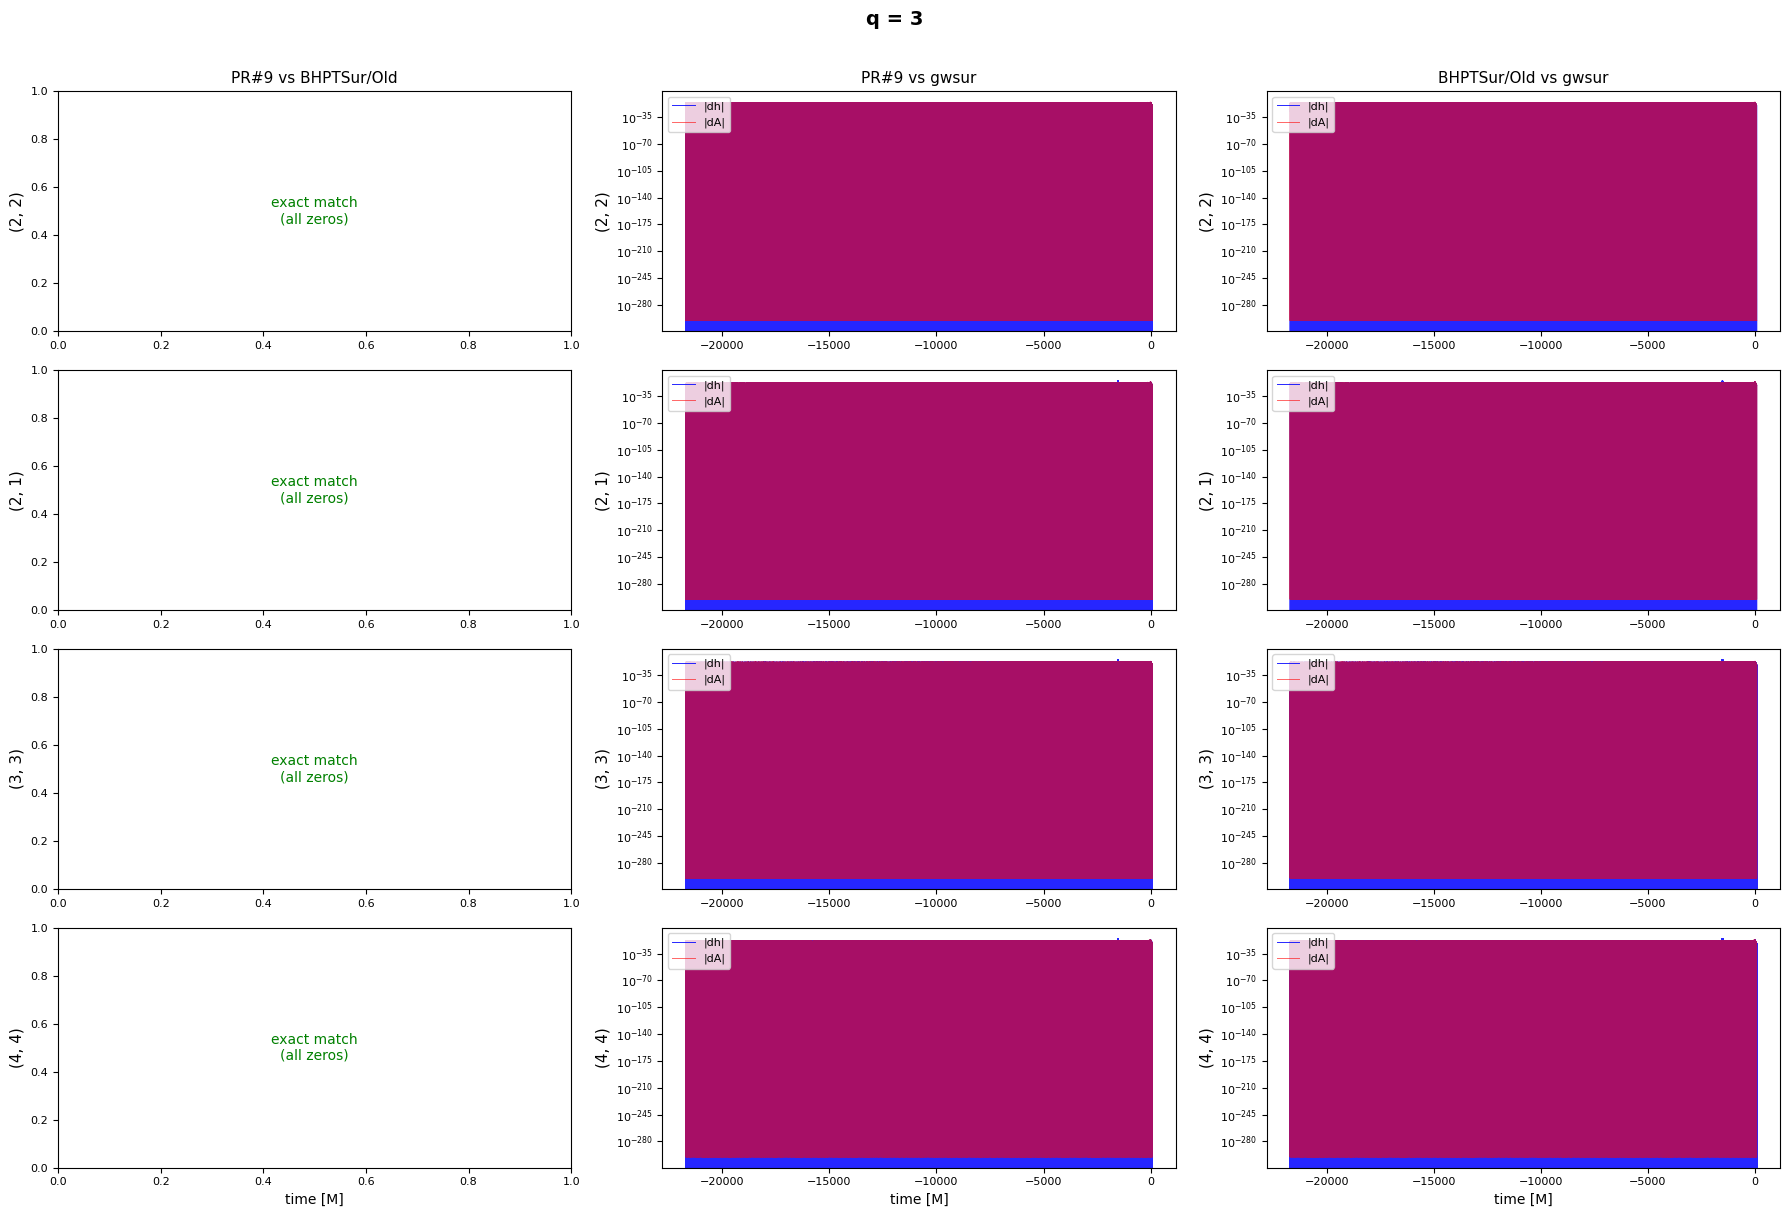

In [7]:
run_test(q=3)

## Test 2: q = 10


  q = 10

  PR#9 vs BHPTSur/Old
      Mode       max|dh|       max|dA|   max|dphi| (rad)
  ────────  ────────────  ────────────  ────────────────
    (2, 1)    0.0000e+00    0.0000e+00        0.0000e+00
    (2, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 1)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 4)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 4)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 5)    0.0000e+00    0.0000e+00        0.0000e+00

  PR#9 vs gwsur
      Mode       max|dh|       max|dA|   max|dphi| (rad)
  ────────  ────────────  ────────────  ────────────────
    (2, 1)    4.0994e-16    2.0817e-17        5.6843e-14
    (2, 2)    3.1032e-17    2.7756e-17

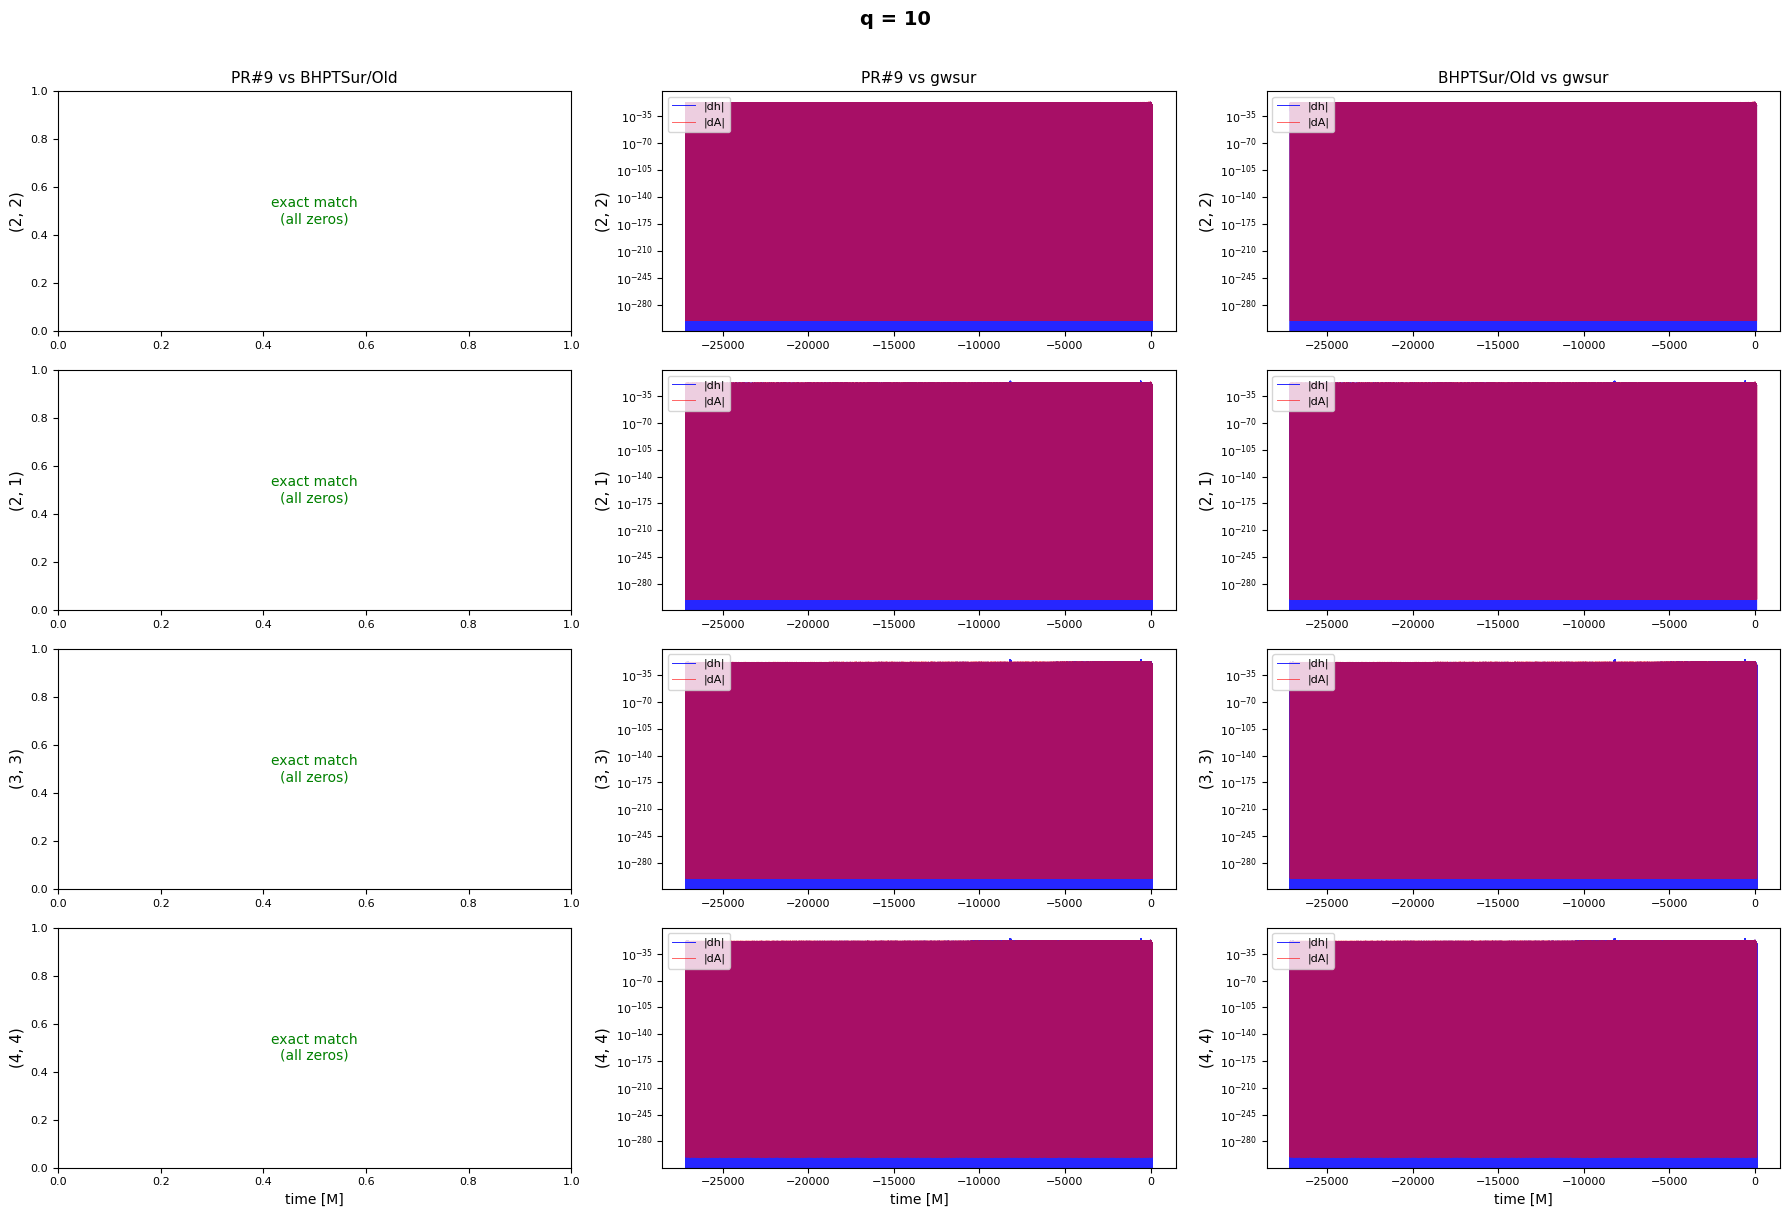

In [8]:
run_test(q=10)

## Test 3: q = 100


  q = 100

  PR#9 vs BHPTSur/Old
      Mode       max|dh|       max|dA|   max|dphi| (rad)
  ────────  ────────────  ────────────  ────────────────
    (2, 1)    0.0000e+00    0.0000e+00        0.0000e+00
    (2, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 1)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (3, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 2)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (4, 4)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 3)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 4)    0.0000e+00    0.0000e+00        0.0000e+00
    (5, 5)    0.0000e+00    0.0000e+00        0.0000e+00

  PR#9 vs gwsur
      Mode       max|dh|       max|dA|   max|dphi| (rad)
  ────────  ────────────  ────────────  ────────────────
    (2, 1)    2.0600e-16    1.7347e-18        1.1369e-13
    (2, 2)    3.4694e-18    5.2042e-1

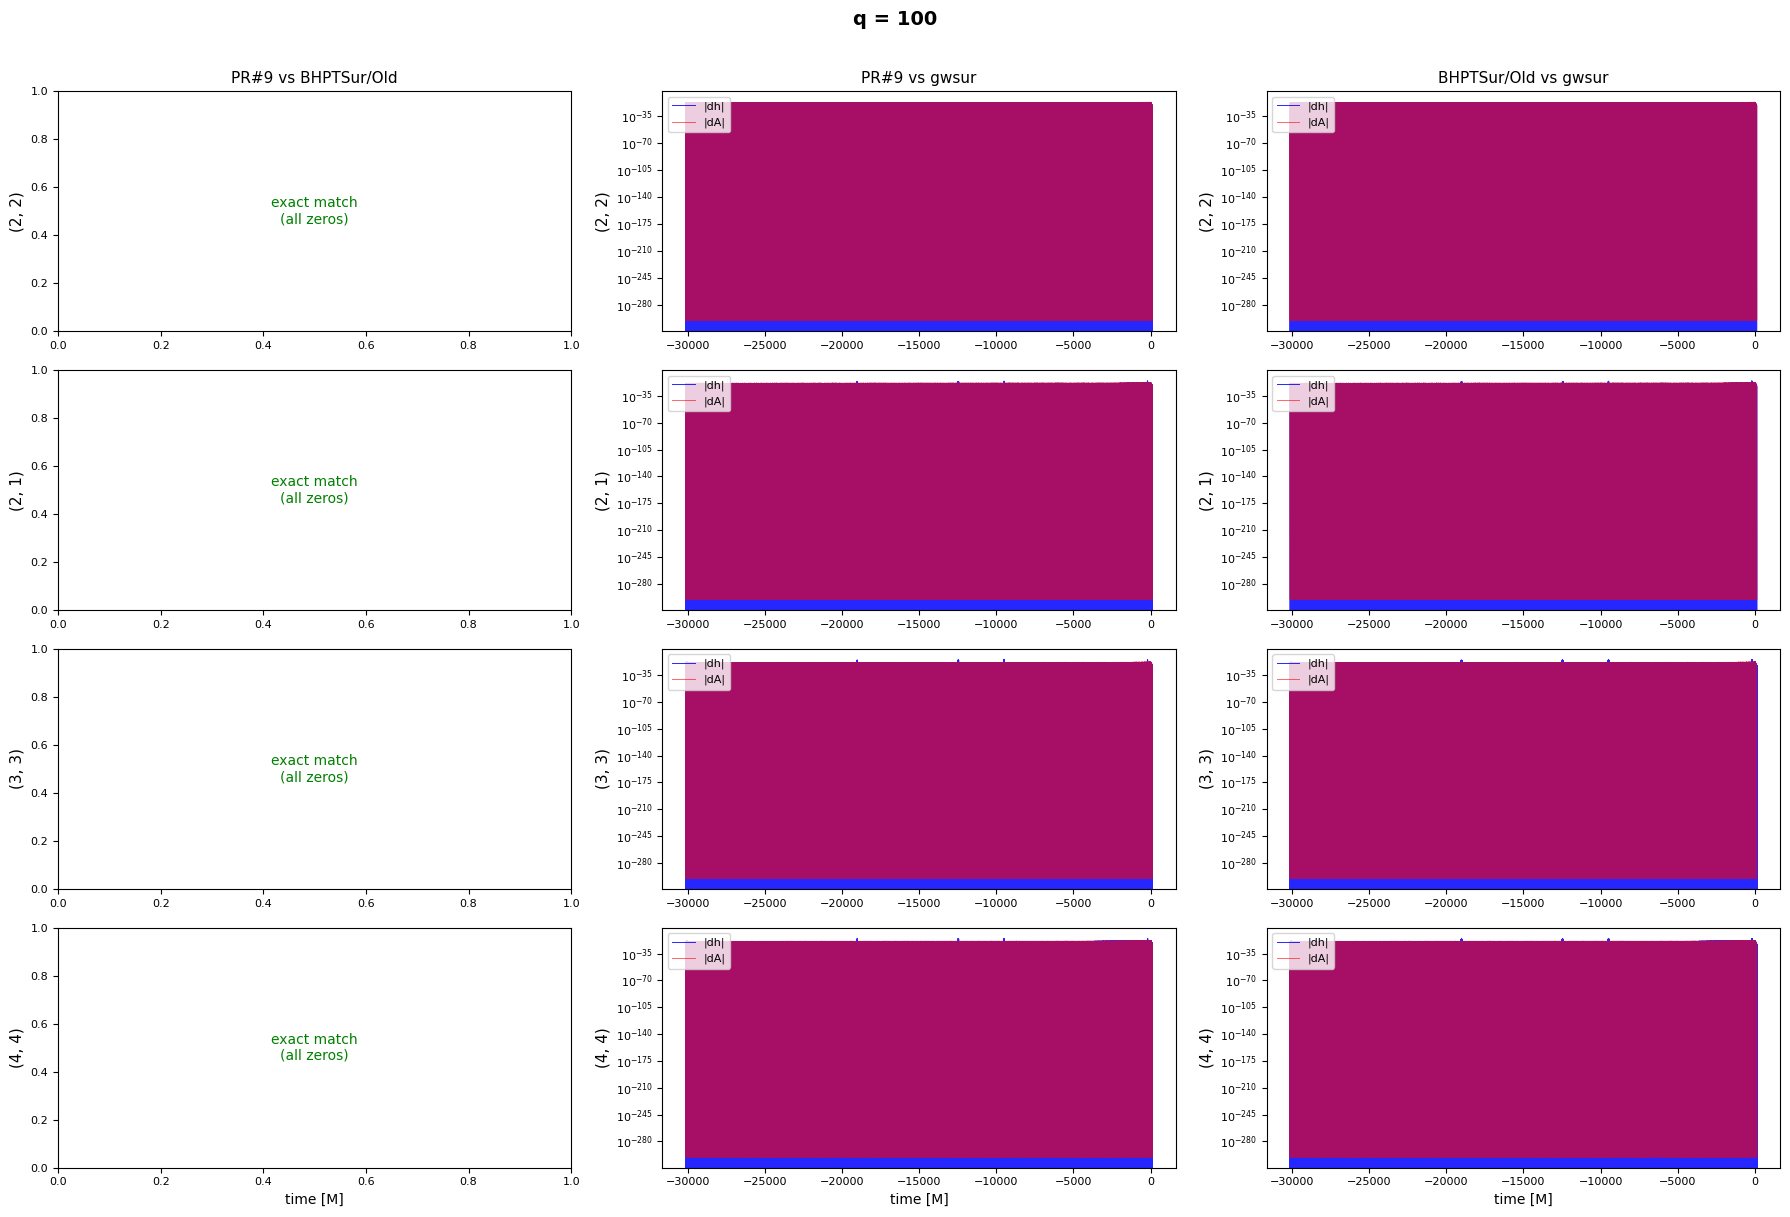

In [9]:
run_test(q=100)